In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import NMF
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import ward, dendrogram, fcluster, linkage, cophenet
from sklearn.preprocessing import normalize
from scipy.sparse import csr_matrix
from nltk.stem import SnowballStemmer

In [2]:
df = pd.read_csv("../coronavirus_dataset_2000-2025.csv")

df.head()

,Unnamed: 0,identifier,doi,publication_year,journal,title,abstract,keywords
0,0,754107200001,10.1080/14639947.2022.2029212,2020,CONTEMP BUDDHISM,"buddhist ""solutions"" and action in the context...",this paper aims to understand the complex and ...,buddhism|covid-19|meditation|lockdown|adaptations
1,1,753006200001,10.1080/21528586.2021.2015624,2020,S AFR REV SOCIOL,homelessness and community based healthcare: a...,this article serves to describe health encount...,community-oriented primary care|street homeles...
2,2,747573400001,10.1080/21528586.2021.2018036,2020,S AFR REV SOCIOL,"fostering integrated, collaborative approaches...",this article maps the covid-19 pandemic and lo...,homelessness|shelters|city of tshwane|collabor...
3,3,652478200009,NaN,2020,CONSERV SCI CULT HER,"environment, food, culture: covid-19",human activities and the exploitation of natur...,covid-19|philosophy of insecurity|culture
4,4,561521500001,10.1080/22221751.2020.1803146,2020,EMERG MICROBES INFEC,"the ongoing covid-19 epidemic in minas gerais,...",the recent emergence of a coronavirus (sars-co...,sars-cov-2|genomic surveillance|minas gerais|s...


I'm going to toss in a vectorizer with no stopwords to start out, and see what the most common terms are.

In [3]:
vectorizer = CountVectorizer(strip_accents='ascii',
                             encoding='ascii',
                             decode_error='ignore',
                             lowercase=True,
                             analyzer="word")
vec = vectorizer.fit_transform(df['abstract'])

KeyboardInterrupt: 

In [5]:
counts = term_mat.sum(axis=0).A[0]
words = vectorizer.get_feature_names_out()

In [6]:
word_count_df = pd.DataFrame(dict({"counts": counts, "words": words}))
word_count_df.sort_values("counts", ascending=False, inplace=True)

In [7]:
word_count_df.head(n=30)

,counts,words
71097,12525.180382,covid
5819,12399.790130,19
188184,9814.790045,patients
186274,7541.272526,pandemic
223218,7117.054943,sars
70803,7063.685020,cov
117380,5948.433764,health
237919,5694.853261,study
130377,4688.993488,infection
84147,4374.657886,disease


Okay, that exploration didn't bear much fruit. Words that are important, like "patients", are higher up than words like "or", which isn't.

We'll just use the built-in english stopwords list, despite any known issues, because it seems like making our own isn't very feasible without removing important data.

Instead of `TfidfTransformer`, use `TfidfVectorizer` for efficiency.

In [4]:
vectorizer = TfidfVectorizer(strip_accents='ascii', analyzer="word", stop_words="english")
term_mat = vectorizer.fit_transform(df['abstract'])

In [13]:
nmfer = NMF(
    n_components=10,
    init="nndsvd", #Docs say this is better for sparseness

            )
nmf = nmfer.fit(term_mat)

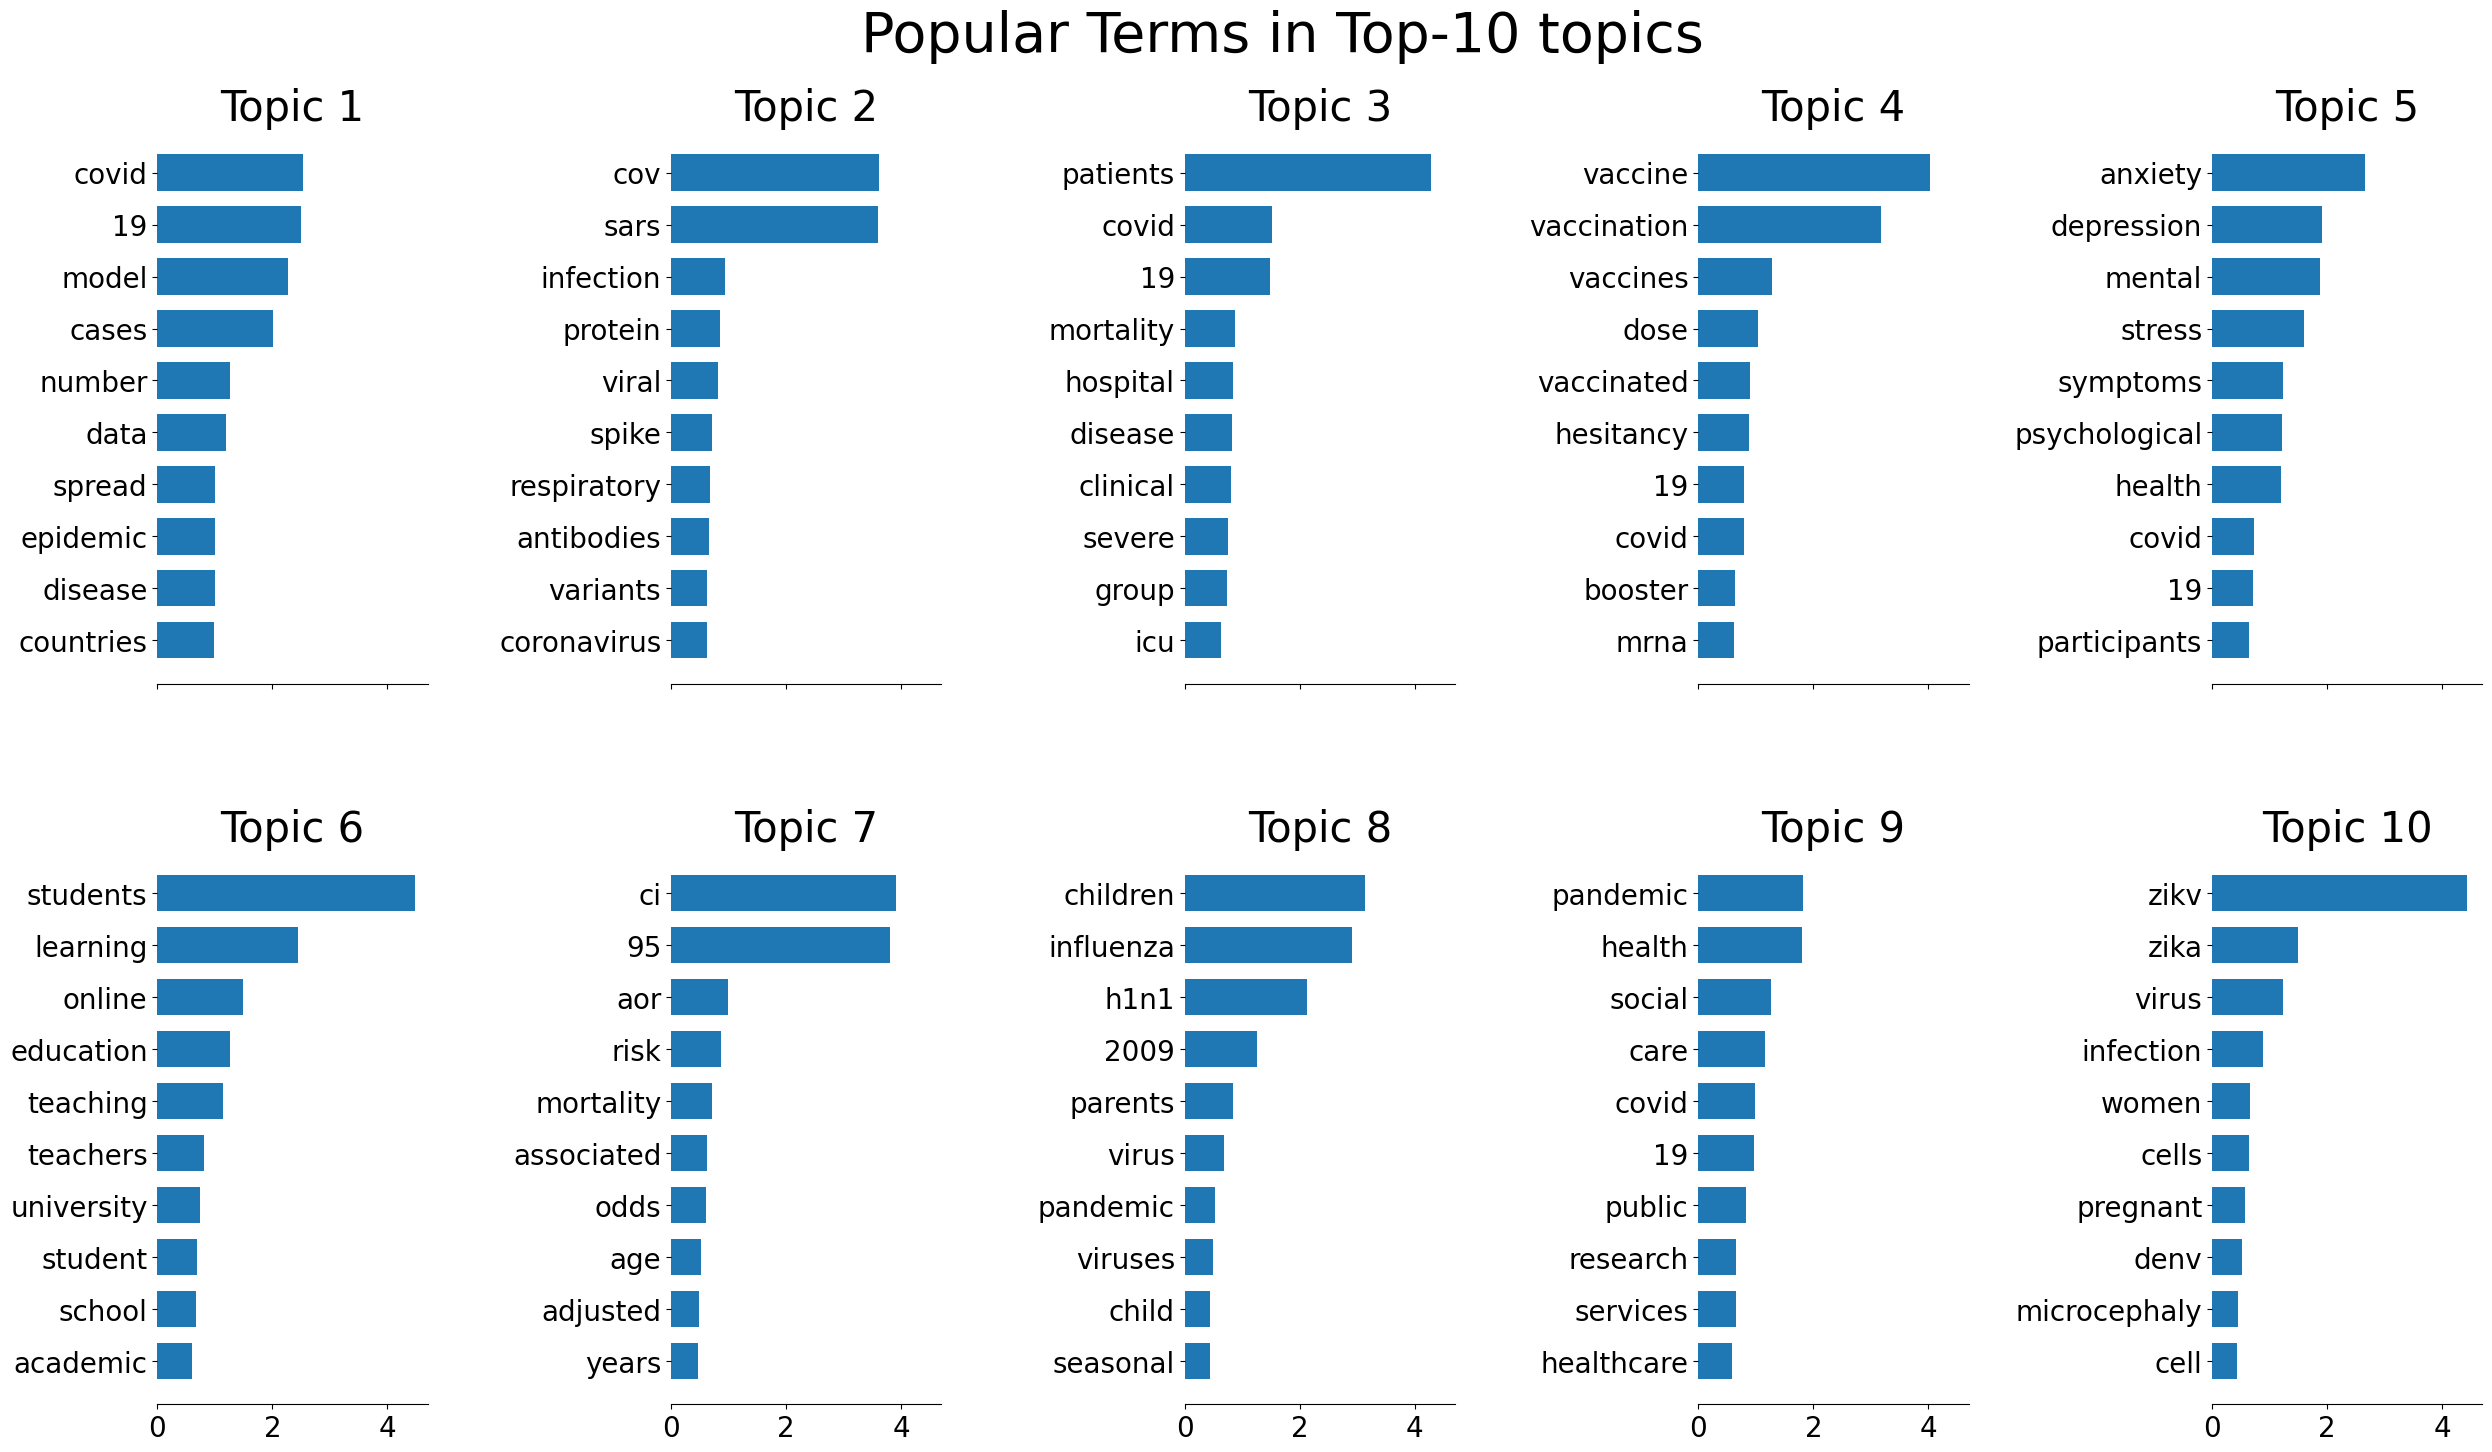

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(30, 15), sharex=True)
axes = axes.flatten()
for topic_idx, topic in enumerate(nmf.components_):
    top_features_ind = topic.argsort()[-10:]
    top_features = vectorizer.get_feature_names_out()[top_features_ind]
    weights = topic[top_features_ind]

    ax = axes[topic_idx]
    ax.barh(top_features, weights, height=0.7)
    ax.set_title(f"Topic {topic_idx + 1}", fontdict={"fontsize": 30})
    ax.tick_params(axis="both", which="major", labelsize=20)
    for i in "top right left".split():
        ax.spines[i].set_visible(False)
    fig.suptitle("Popular Terms in Top-10 topics", fontsize=40)

plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
plt.show()

Let's get something in before midnight

([<matplotlib.patches.Wedge at 0x7f2933602490>,
 [Text(-0.16582180200751626, 1.0874295977114934, 'covid-19'),
  Text(-0.7798491946510793, -0.7757804029505148, 'sars-cov-2'),
  Text(-0.1541360896867086, -1.0891474031810804, 'pandemic'),
  Text(0.18435156331590072, -1.0844420229329845, 'coronavirus'),
  Text(0.46137123741717, -0.9985672642762476, 'covid-19 pandemic'),
  Text(0.6565361733328221, -0.8825872495711088, 'mental health'),
  Text(0.7797332342336261, -0.775896954132164, 'anxiety'),
  Text(0.8706782727670214, -0.6722494665906672, 'mortality'),
  Text(0.9461389295318804, -0.5610892317842747, 'vaccination'),
  Text(1.0054654806543175, -0.4461380584668634, 'depression'),
  Text(1.0484959696988194, -0.3326502690895237, 'public health'),
  Text(1.0762713968333832, -0.22724409862154474, 'vaccine'),
  Text(1.0923196090354297, -0.12976082504626002, 'epidemiology'),
  Text(1.099252481380261, -0.04054605010773387, 'lockdown')])

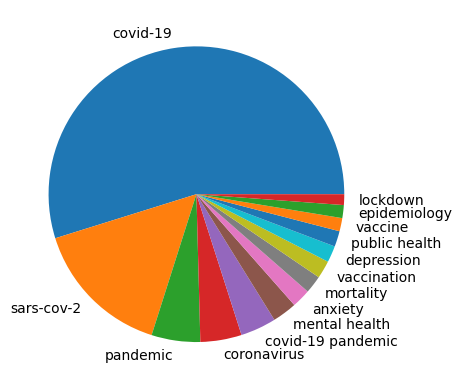

In [64]:
d = dict()
for item in df["keywords"]:
    if str(item) != 'nan':
        kws = item.split("|")
        for jtem in kws:
            jtem = jtem.lower()
            if jtem not in d:
                d[jtem] = 1
            else:
                d[jtem] += 1


l = [(item[1], item[0]) for item in d.items()]
s = sorted(l, key=lambda key: key[0])
top50 = s[-1:-15:-1]
plt.pie([item[0] for item in top50], labels=[item[1] for item in top50])

([<matplotlib.patches.Wedge at 0x7f2934895d10>,
 [Text(-0.16582180200751626, 1.0874295977114934, 'covid-19'),
  Text(-0.7798491946510793, -0.7757804029505148, 'sars-cov-2'),
  Text(-0.1541360896867086, -1.0891474031810804, 'pandemic'),
  Text(0.18435156331590072, -1.0844420229329845, 'coronavirus'),
  Text(0.46137123741717, -0.9985672642762476, 'covid-19 pandemic'),
  Text(0.6565361733328221, -0.8825872495711088, 'mental health'),
  Text(0.7797332342336261, -0.775896954132164, 'anxiety'),
  Text(0.8706782727670214, -0.6722494665906672, 'mortality'),
  Text(0.9461389295318804, -0.5610892317842747, 'vaccination'),
  Text(1.0054654806543175, -0.4461380584668634, 'depression'),
  Text(1.0484959696988194, -0.3326502690895237, 'public health'),
  Text(1.0762713968333832, -0.22724409862154474, 'vaccine'),
  Text(1.0923196090354297, -0.12976082504626002, 'epidemiology'),
  Text(1.099252481380261, -0.04054605010773387, 'lockdown')])

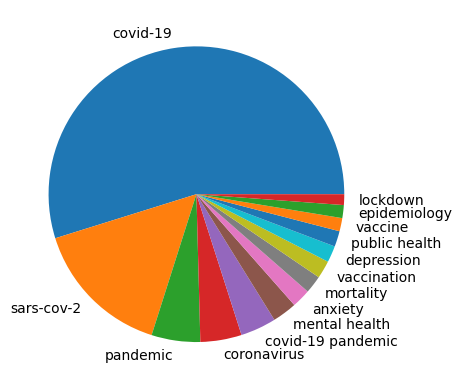